Extracting features... this might take a minute...
All done! Saved features to time_domain_features.csv


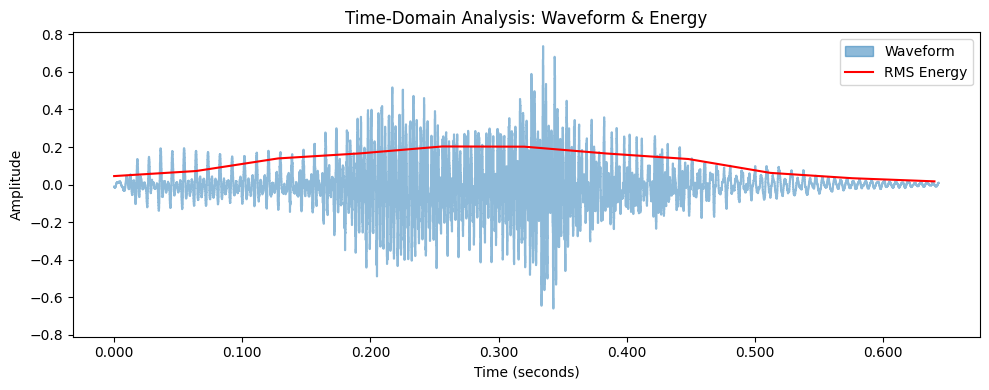

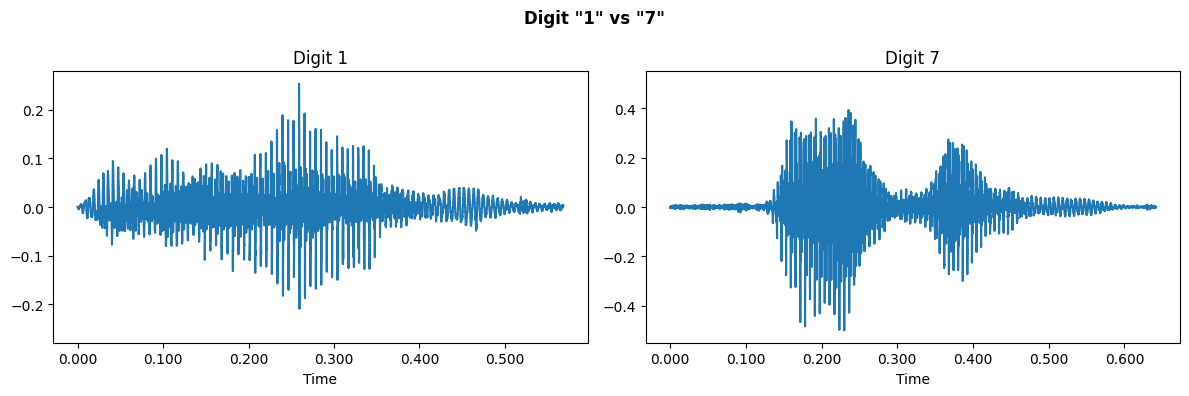

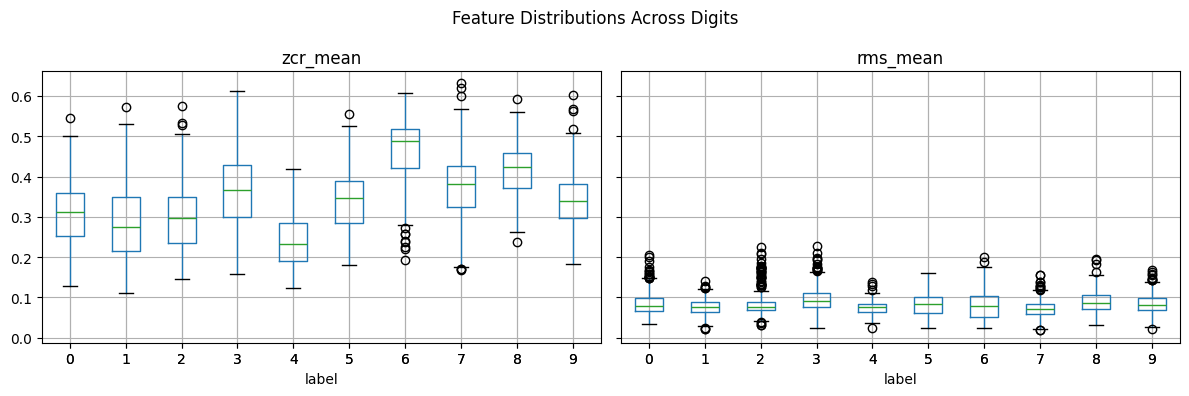

In [4]:
!unzip -o -q free-spoken-digit-dataset-master.zip
import os
import librosa
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.signal import hilbert

# This path is specifically for Google Colab
DATA_DIR = "/content/free-spoken-digit-dataset-master/recordings"

def get_time_features(signal):
    """Processes the signal and extracts time-domain features efficiently."""

    # 1. Normalize volume to be between -1 and 1
    if np.max(np.abs(signal)) > 0:
        signal = signal / np.max(np.abs(signal))

    # 2. Pre-emphasis filter (boosts high frequencies to make speech clearer)
    signal = np.append(signal[0], signal[1:] - 0.97 * signal[:-1])

    # 3. Extract features using librosa
    zcr = librosa.feature.zero_crossing_rate(signal)[0]
    rms = librosa.feature.rms(y=signal)[0]

    # 4. Autocorrelation (helps find pitch)
    autocorr = librosa.autocorrelate(signal)
    autocorr[:20] = 0  # Ignore the first huge peak

    # 5. Signal Envelope (the outer shape of the audio wave)
    env = np.abs(hilbert(signal))

    return {
        'zcr_mean': np.mean(zcr),
        'zcr_var': np.var(zcr),
        'rms_mean': np.mean(rms),
        'rms_var': np.var(rms),
        'autocorr_peak': np.max(autocorr) if len(autocorr) > 0 else 0,
        'env_mean': np.mean(env)
    }

def process_dataset(data_dir):
    """Loops through all audio files, extracts features, and saves to CSV."""
    data = []

    print("Extracting features... this might take a minute...")
    for file in os.listdir(data_dir):
        if file.endswith('.wav'):
            parts = file.replace('.wav', '').split('_')
            label, speaker = parts[0], parts[1]

            sig, sr = librosa.load(os.path.join(data_dir, file), sr=None)
            features = get_time_features(sig)

            features.update({'label': label, 'speaker': speaker, 'filename': file})
            data.append(features)

    df = pd.DataFrame(data)
    df.to_csv('time_domain_features.csv', index=False)
    print("All done! Saved features to time_domain_features.csv")
    return df

def plot_signal(file_path):
    """Creates a visualization of the audio wave and its energy."""
    # Visualization made with claude
    sig, sr = librosa.load(file_path, sr=None)

    rms = librosa.feature.rms(y=sig)[0]
    times = librosa.frames_to_time(range(len(rms)), sr=sr)

    plt.figure(figsize=(10, 4))
    librosa.display.waveshow(sig, sr=sr, alpha=0.5, label='Waveform')
    plt.plot(times, rms, color='red', label='RMS Energy')

    plt.title('Time-Domain Analysis: Waveform & Energy')
    plt.xlabel('Time (seconds)')
    plt.ylabel('Amplitude')
    plt.legend()
    plt.tight_layout()
    plt.show()

def plot_digit_comparison(data_dir, d1='1', d2='7'):
    """Compares waveforms of two digits side by side."""
    # Visualization made with claude
    file1 = next(f for f in sorted(os.listdir(data_dir)) if f.startswith(f'{d1}_'))
    file2 = next(f for f in sorted(os.listdir(data_dir)) if f.startswith(f'{d2}_'))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    for ax, f in zip(axes, [file1, file2]):
        sig, sr = librosa.load(os.path.join(data_dir, f), sr=None)
        librosa.display.waveshow(sig, sr=sr, ax=ax)
        ax.set_title(f'Digit {f[0]}')
    plt.suptitle(f'Digit "{d1}" vs "{d2}"', fontweight='bold')
    plt.tight_layout()
    plt.show()

def plot_distributions(df):
    """Box plots showing ZCR and RMS across all digits."""
    # Visualization made with claude
    df.boxplot(column=['zcr_mean', 'rms_mean'], by='label', figsize=(12, 4))
    plt.suptitle('Feature Distributions Across Digits')
    plt.tight_layout()
    plt.show()

# --- EXECUTION ---

# 1. Process the entire dataset and create the CSV
df = process_dataset(DATA_DIR)

# 2. Plot waveform and energy for a sample file
sample_file = os.path.join(DATA_DIR, "0_jackson_0.wav")
if os.path.exists(sample_file):
    plot_signal(sample_file)
else:
    print(f"Could not find {sample_file} to plot. Check your unzipped folder!")

# 3. Compare two digits
plot_digit_comparison(DATA_DIR, '1', '7')

# 4. Show feature distributions across all digits
plot_distributions(df)